# Домашнє завдання

Вже готові виконувати нове завдання? Тодi полетiли!

Сьогодні використаємо знання, отримані про ланцюги Маркова та марковські процеси ухвалення рішень для розв'язання задачі навчання з підкріпленням.

Це допоможе закрiпити наступні навички:  

- елементи ланцюгів Маркова;
- основні поняття навчання з підкріпленням.

## Завдання (крок за кроком)

Для цієї задачі необхідно буде завантажити середовище FrozenLake-v1 з бібліотеки Open AI Gym.

 Для виконання завдання необхідно виконати такі кроки:

1. Завантажити середовище за допомогою gym.make('FrozenLake-v1').  

2. Використовуючи опис функції compute_value_function() в конспекті у розділі Ітерації за політиками запрограмувати її повний вигляд.

3. Використовуючи опис функції policy_iteration() в конспекті у розділі Ітерації за політиками запрограмувати її повний вигляд.

4. Візуалізувати отриману оптимальну політику за допомогою функції show_render() з конспекта.


## Пiдказки

Для виконання завдання використовуйте функції та алгоритми з конспекту до цієї теми.

## Формат здачі

Посилання на Google Colab, прикріплений файл ipynb

## Критерії прийому

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

## Формат оцінювання
- Залік/Незалік

## Приклад

Q-learning for beginners

https://medium.com/data-science/q-learning-for-beginners-2837b777741

Sai Sasank. Introduction to RL

https://medium.com/swlh/introduction-to-rl-c70495366298

Sai Sasank. Frozen-Lake as a Markov Decision Process

https://medium.com/swlh/frozen-lake-as-a-markov-decision-process-1692815ecfd1

https://github.com/SasankYadati/FrozenLake-DP/tree/main

**Навчання з підкріпленням** передбачає оціночний зворотний зв'язок, який оцінює виконані дії, на відміну від інструктивного зворотного зв'язку, який вказує на правильні дії. Оціночний зворотний зв'язок залежить від виконаної дії, тоді як інструктивний зворотний зв'язок не залежить від дії.

**Визначаємо політику** як відображення станів у розподіли ймовірностей за діями. Політика інформує агента про дію, яку потрібно виконати в будь-якому заданому стані.

In [1]:
!ls


sample_data


In [2]:
!pip install -U gym
!pip install numpy==1.23.5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 8.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827726 sha256=32a7a9aaae4052a6cb5116c7066833cd270e4b9cc0c34f1edd8abfb2c73cc5f5
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.2 MB/s eta 0:00:00
  Installing build dep

In [3]:
!git clone https://github.com/SasankYadati/FrozenLake-DP.git FrozenLakeDP

Cloning into 'FrozenLakeDP'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 48 (delta 22), reused 37 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 145.71 KiB | 4.86 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [4]:
%pip uninstall -y numpy
%pip install "numpy<2"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13

**Зверність увагу, що після попереднього блоку коду, зазвичай з'являється повідомлення про необхідність перезапуску обчислень. В цьому випадку, можна просто запустити виконання з наступної комірки коду**

In [1]:
import gym
from FrozenLakeDP.MarkovDecisionProcess import MarkovDecisionProcess as MDP
from FrozenLakeDP.Agent import Agent
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')
env = gym.make('FrozenLake-v1')
env.reset()
mdp = MDP(env.observation_space.n, env.action_space.n, env.unwrapped.P)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def run_experiment(env, agent, num_runs=1, render=False):
    tot_reward = [0]
    for _ in range(num_runs):
        observation = 0
        done = False
        env.reset()
        render and env.render()
        reward_per_run = 0
        while not done:
            action = agent.get_action(observation)
            observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            reward_per_run += reward
            render and env.render()
        env.close()
        tot_reward.append(reward_per_run + tot_reward[-1])
    return tot_reward

/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


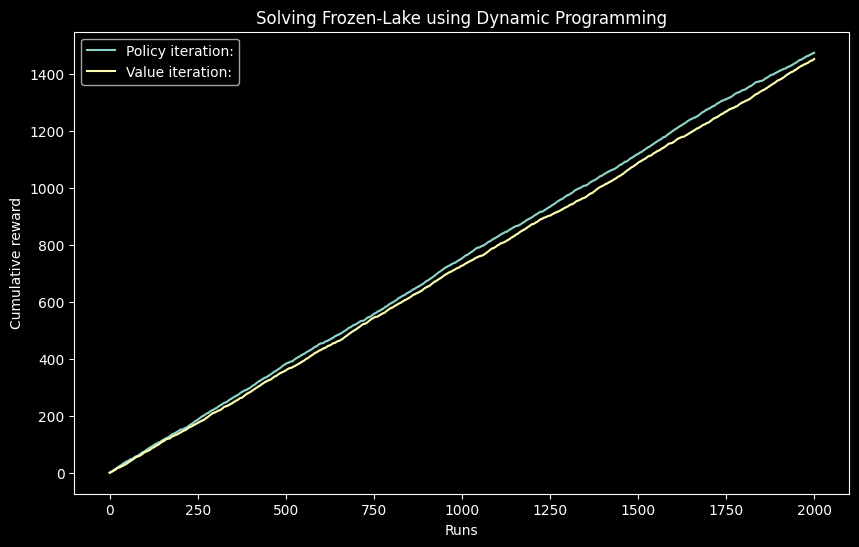

In [3]:
agent1 = Agent(mdp, 1, 0.000001)
agent1.policy_iteration()

agent2 = Agent(mdp, 1, 0.000001)
agent2.value_iteration()

num_runs = 2000
cumulative_rewards1 = run_experiment(env, agent1, num_runs)
cumulative_rewards2 = run_experiment(env, agent2, num_runs)

fig, ax = plt.subplots(figsize=(10, 6))  # Create a figure and an axes.
ax.plot(range(num_runs+1), cumulative_rewards1, label="Policy iteration:")
ax.plot(range(num_runs+1), cumulative_rewards2, label="Value iteration:")
ax.grid(False)
ax.set_xlabel('Runs')  # Add an x-label to the axes.
ax.set_ylabel('Cumulative reward')  # Add a y-label to the axes.
ax.set_title("Solving Frozen-Lake using Dynamic Programming")  # Add a title to the axes.
ax.legend()  # Add a legend.


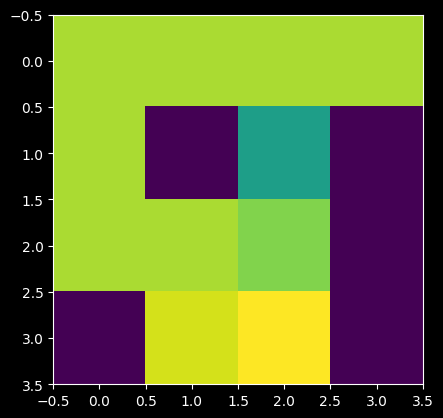

In [4]:
X1 = np.reshape(agent2.value_fn, (4,4))
fig, ax = plt.subplots()
ax.imshow(X1, interpolation="nearest")
plt.show()

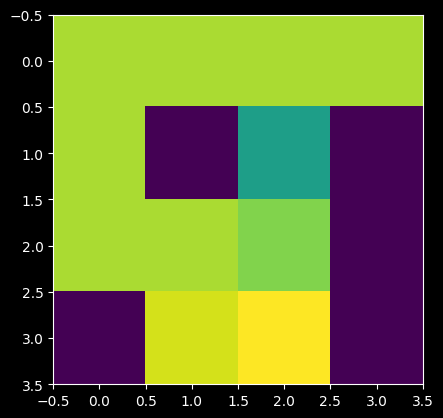

In [5]:
X2 = np.reshape(agent2.value_fn, (4,4))
fig, ax = plt.subplots()
ax.imshow(X2, interpolation="nearest")
plt.show()

In [6]:
print(agent1.value_fn)
print(agent2.value_fn)

[0.823512176186304, 0.8235065214065564, 0.8235025912744336, 0.8235005915190245, 0.8235139099285893, 0.0, 0.5294000122045985, 0.0, 0.8235166251003787, 0.8235201067130089, 0.7646977282349576, 0.0, 0.0, 0.8823464740665202, 0.9411731799512619, 0.0]
[0.8235122789674345, 0.8235066579092396, 0.8235027512139779, 0.82350076338387, 0.8235140023708973, 0.0, 0.52940008228867, 0.0, 0.8235167013513003, 0.8235201622020147, 0.7646977768606238, 0.0, 0.0, 0.8823465126319712, 0.9411731995743859, 0.0]


In [7]:
import timeit
policy_iteration_setup = '''
import gym
from FrozenLakeDP.MarkovDecisionProcess import MarkovDecisionProcess as MDP
from FrozenLakeDP.Agent import Agent
env = gym.make('FrozenLake-v1')
env.reset()
mdp = MDP(env.observation_space.n, env.action_space.n, env.unwrapped.P)
agent = Agent(mdp, 1, 0.000001)
'''
policy_iteration_code = "agent.policy_iteration()"
value_iteration_setup = '''
import gym
from FrozenLakeDP.MarkovDecisionProcess import MarkovDecisionProcess as MDP
from FrozenLakeDP.Agent import Agent
env = gym.make('FrozenLake-v1')
env.reset()
mdp = MDP(env.observation_space.n, env.action_space.n, env.unwrapped.P)
agent = Agent(mdp, 1, 0.000001)
'''
value_iteration_code = "agent.value_iteration()"


In [8]:
num_runs_options = [1, 10, 50, 100, 500, 1000]
pi_time = []
vi_time = []
for num_runs in num_runs_options:
    pi_time.append(timeit.timeit(setup=policy_iteration_setup, stmt=policy_iteration_code, number=num_runs))
    vi_time.append(timeit.timeit(setup=value_iteration_setup, stmt=value_iteration_code, number=num_runs))

In [9]:
print(pi_time, vi_time)

[0.32082082899998454, 0.6257287589999976, 0.5517484330000002, 0.898848978999979, 1.1157993869999814, 1.4822851149999963] [0.02249283599999785, 0.04805979100001423, 0.08942407999998636, 0.14115907299998298, 0.35104718200000207, 0.6627988010000081]


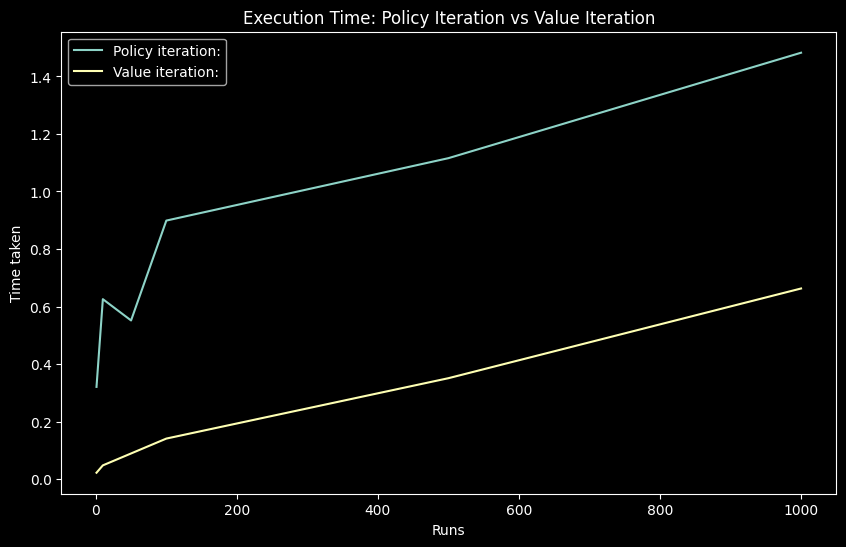

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create a figure and an axes.
ax.plot(num_runs_options, pi_time, label="Policy iteration:")
ax.plot(num_runs_options, vi_time, label="Value iteration:")
ax.grid(False)
ax.set_xlabel('Runs')  # Add an x-label to the axes.
ax.set_ylabel('Time taken')  # Add a y-label to the axes.
ax.set_title("Execution Time: Policy Iteration vs Value Iteration")  # Add a title to the axes.
ax.legend()  # Add a legend.


In [11]:
import gym
from FrozenLakeDP.MarkovDecisionProcess import MarkovDecisionProcess as MDP
env = gym.make('FrozenLake-v1', render_mode="rgb_array")
env.reset()
env.render()
mdp = MDP(env.observation_space.n, env.action_space.n, env.unwrapped.P)
print("Number of states ", mdp.num_states)
print("Number of actions ", mdp.num_actions)
sample_actions = {'LEFT':0, 'UP':3}
sample_states = [0,11,15]
for s in sample_states:
    for a in sample_actions.keys():
        print(f"Transitions for state {s} and action {a} are\n ", mdp.P[s][sample_actions[a]])

Number of states  16
Number of actions  4
Transitions for state 0 and action LEFT are
  [(0.3333333333333333, 0, 0.0, False), (0.3333333333333333, 0, 0.0, False), (0.3333333333333333, 4, 0.0, False)]
Transitions for state 0 and action UP are
  [(0.3333333333333333, 1, 0.0, False), (0.3333333333333333, 0, 0.0, False), (0.3333333333333333, 0, 0.0, False)]
Transitions for state 11 and action LEFT are
  [(1.0, 11, 0, True)]
Transitions for state 11 and action UP are
  [(1.0, 11, 0, True)]
Transitions for state 15 and action LEFT are
  [(1.0, 15, 0, True)]
Transitions for state 15 and action UP are
  [(1.0, 15, 0, True)]


---
# Виконання домашнього завдання: ітерація за політиками для FrozenLake-v1

**План виконання (крок за кроком):**

1. Завантажити середовище `FrozenLake-v1` та дослідити його як марковський процес ухвалення рішень (MDP).
2. Запрограмувати функцію `compute_value_function()` — **оцінювання політики** (policy evaluation).
3. Запрограмувати функцію `policy_iteration()` — **ітерацію за політиками** (разом з допоміжною функцією `extract_policy()` — покращення політики).
4. Візуалізувати отриману оптимальну політику за допомогою `show_render()`.
5. Провести обчислювальні експерименти з різними значеннями коефіцієнта дисконтування $\gamma$ та порівняти з випадковою політикою.
6. Зробити висновки.

## Крок 1. Завантаження середовища `FrozenLake-v1`

**FrozenLake** — це сітка $4\times4$:

| Символ | Значення |
|---|---|
| `S` | старт (стан 0) |
| `F` | замерзла поверхня (безпечно) |
| `H` | ополонка (термінальний стан, винагорода 0) |
| `G` | ціль (термінальний стан, винагорода +1) |

- **Стани** $S = \{0,\dots,15\}$ — номер клітинки (рядок·4 + стовпець).
- **Дії** $A = \{0: \leftarrow,\ 1: \downarrow,\ 2: \rightarrow,\ 3: \uparrow\}$.
- **Функція переходів** $P(s'\mid s,a)$: лід слизький (`is_slippery=True`), тому агент рухається в обраному напрямку лише з імовірністю $1/3$, а з імовірністю $1/3$ — в кожен із двох перпендикулярних напрямків.
- **Винагорода** $R = 1$ лише при досягненні `G`.

Модель середовища доступна у словнику `env.unwrapped.P[s][a]` у вигляді списку кортежів `(ймовірність, наступний_стан, винагорода, термінальний)`.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Кількість станів : 16
Кількість дій    : 4
Карта озера:
SFFF
FHFH
FFFH
HFFG

Переходи зі стану 0 при дії RIGHT (2):
  p=0.333 -> s'= 4, r=0.0, done=False
  p=0.333 -> s'= 1, r=0.0, done=False
  p=0.333 -> s'= 0, r=0.0, done=False


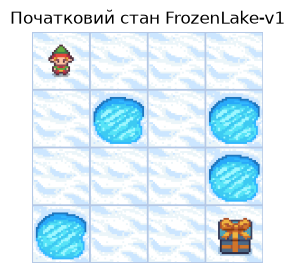

In [1]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

plt.style.use('default')

# Крок 1: завантажуємо середовище
env = gym.make('FrozenLake-v1', render_mode='rgb_array')
state, info = env.reset(seed=42)

n_states = env.observation_space.n
n_actions = env.action_space.n
P = env.unwrapped.P          # модель MDP: P[s][a] -> [(prob, s_next, reward, done), ...]
desc = env.unwrapped.desc.astype(str)

print('Кількість станів :', n_states)
print('Кількість дій    :', n_actions)
print('Карта озера:')
print('\n'.join(''.join(row) for row in desc))
print('\nПереходи зі стану 0 при дії RIGHT (2):')
for p, s_next, r, done in P[0][2]:
    print(f'  p={p:.3f} -> s\'={s_next:2d}, r={r}, done={done}')

plt.figure(figsize=(3, 3))
plt.imshow(env.render())
plt.axis('off')
plt.title('Початковий стан FrozenLake-v1')
plt.show()

## Крок 2. Функція `compute_value_function()` — оцінювання політики

Для заданої детермінованої політики $\pi$ функція цінності стану задовольняє **рівняння Беллмана для очікування**:

$$
V^{\pi}(s) = \sum_{s'} P\big(s' \mid s, \pi(s)\big)\,\Big[R(s,\pi(s),s') + \gamma\,V^{\pi}(s')\Big].
$$

Розв'язуємо його ітеративно: починаємо з $V(s)=0$ і багаторазово застосовуємо праву частину рівняння до всіх станів, доки сумарна зміна значень $\sum_s |V_{k+1}(s) - V_k(s)|$ не стане меншою за поріг `threshold`.

In [2]:
def compute_value_function(policy, gamma=1.0, threshold=1e-10):
    # Оцінювання політики: повертає V^pi(s) для кожного стану.
    value_table = np.zeros(n_states)
    while True:
        updated_value_table = np.copy(value_table)
        for state in range(n_states):
            action = policy[state]
            # рівняння Беллмана для очікування
            value_table[state] = sum(
                trans_prob * (reward + gamma * updated_value_table[next_state])
                for trans_prob, next_state, reward, _ in P[state][action]
            )
        # критерій зупинки
        if np.sum(np.fabs(updated_value_table - value_table)) <= threshold:
            break
    return value_table


# Перевірка: оцінимо «наївну» політику — завжди рухатися вправо (дія 2)
always_right = np.full(n_states, 2)
V_right = compute_value_function(always_right, gamma=1.0)
print('V для політики "завжди вправо":')
print(np.round(V_right.reshape(4, 4), 3))

V для політики "завжди вправо":
[[0.032 0.024 0.048 0.   ]
 [0.039 0.    0.095 0.   ]
 [0.086 0.219 0.238 0.   ]
 [0.    0.419 0.619 0.   ]]


### Допоміжна функція `extract_policy()` — покращення політики

Маючи функцію цінності $V$, обчислюємо Q-функцію та обираємо **жадібну** дію в кожному стані:

$$
Q(s,a) = \sum_{s'} P(s' \mid s,a)\,\big[R(s,a,s') + \gamma V(s')\big], \qquad
\pi'(s) = \arg\max_a Q(s,a).
$$

In [3]:
def extract_policy(value_table, gamma=1.0):
    # Покращення політики: жадібна політика відносно value_table.
    policy = np.zeros(n_states, dtype=int)
    for state in range(n_states):
        Q_table = np.zeros(n_actions)
        for action in range(n_actions):
            Q_table[action] = sum(
                trans_prob * (reward + gamma * value_table[next_state])
                for trans_prob, next_state, reward, _ in P[state][action]
            )
        policy[state] = np.argmax(Q_table)
    return policy

## Крок 3. Функція `policy_iteration()` — ітерація за політиками

Алгоритм чергує два етапи:

1. **Оцінювання політики** — `compute_value_function(policy)` → $V^{\pi}$;
2. **Покращення політики** — `extract_policy(V)` → $\pi'$.

Починаємо з довільної (тут — нульової, «завжди вліво») політики. Якщо після покращення політика не змінилася ($\pi' = \pi$), то вона задовольняє рівняння оптимальності Беллмана, тобто є **оптимальною** $\pi^*$.

In [4]:
def policy_iteration(env, gamma=1.0, no_of_iterations=200000, verbose=True):
    # Повертає оптимальну політику, її функцію цінності та кількість ітерацій.
    random_policy = np.zeros(env.observation_space.n, dtype=int)   # початкова політика
    for i in range(no_of_iterations):
        new_value_function = compute_value_function(random_policy, gamma)   # 1) оцінювання
        new_policy = extract_policy(new_value_function, gamma)             # 2) покращення
        if np.all(random_policy == new_policy):                            # політика стабільна
            if verbose:
                print(f'Policy-Iteration converged at step {i + 1}.')
            return new_policy, new_value_function, i + 1
        random_policy = new_policy
    return new_policy, new_value_function, no_of_iterations


optimal_policy, optimal_V, n_iter = policy_iteration(env, gamma=1.0)

action_names = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}
arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

print('\nОптимальна політика (номери дій):')
print(optimal_policy.reshape(4, 4))
print('\nОптимальна функція цінності V*(s):')
print(np.round(optimal_V.reshape(4, 4), 4))

Policy-Iteration converged at step 7.

Оптимальна політика (номери дій):
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

Оптимальна функція цінності V*(s):
[[0.8235 0.8235 0.8235 0.8235]
 [0.8235 0.     0.5294 0.    ]
 [0.8235 0.8235 0.7647 0.    ]
 [0.     0.8824 0.9412 0.    ]]


## Крок 4. Візуалізація оптимальної політики

Функція `show_render()` з конспекту відображає поточний кадр середовища (оновлюючи зображення в комірці). Використаємо її, щоб «програти» епізод, у якому агент діє за оптимальною політикою. Оскільки після `clear_output` у збереженому ноутбуці лишається лише останній кадр, додатково зберігаємо всі кадри та показуємо траєкторію статично.

Також побудуємо карту політики: стрілки — дія в кожному стані, колір — значення $V^*(s)$.

In [5]:
def show_render(img, render):
    # Оновлює зображення поточного кадру середовища (з конспекту).
    img.set_data(render)
    plt.axis('off')
    display.display(plt.gcf())
    display.clear_output(wait=True)


def play_episode(env, policy, seed=None, max_steps=100, animate=True):
    # Програє епізод за політикою, повертає кадри, траєкторію та винагороду.
    state, _ = env.reset(seed=seed)
    frames, states, total_reward = [env.render()], [state], 0.0
    if animate:
        img = plt.imshow(frames[0])
    for _ in range(max_steps):
        state, reward, terminated, truncated, _ = env.step(policy[state])
        frames.append(env.render())
        states.append(state)
        total_reward += reward
        if animate:
            show_render(img, frames[-1])
        if terminated or truncated:
            break
    if animate:
        plt.close()
    return frames, states, total_reward


# Шукаємо успішний епізод для демонстрації (лід слизький, тож не кожен епізод успішний)
for seed in range(100):
    frames, states, R = play_episode(env, optimal_policy, seed=seed, animate=(seed == 0))
    if R == 1.0:
        break
print(f'seed={seed}, кроків: {len(states) - 1}, винагорода: {R}')
print('Траєкторія станів:', states)

seed=1, кроків: 41, винагорода: 1.0
Траєкторія станів: [0, 4, 0, 4, 0, 0, 4, 4, 4, 0, 4, 4, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 8, 8, 4, 0, 0, 4, 4, 0, 0, 4, 4, 8, 9, 13, 14, 13, 14, 15]


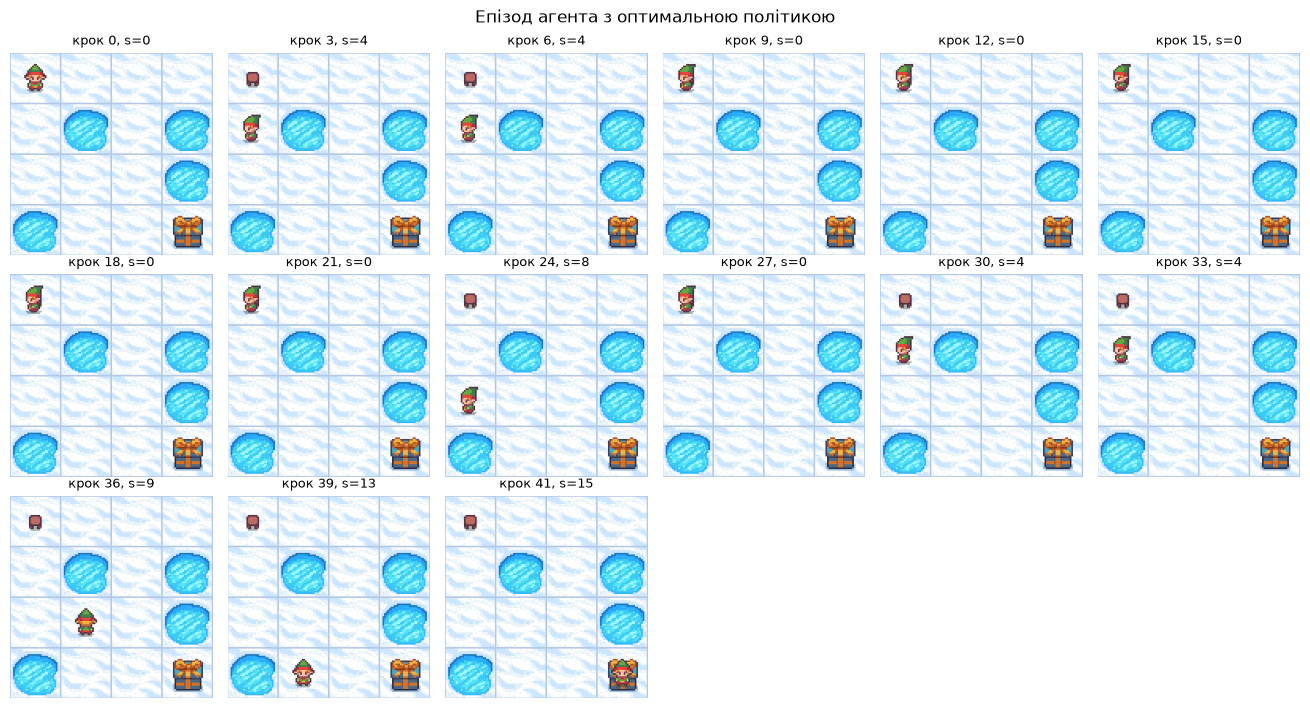

In [6]:
# Статичний показ траєкторії (кожен k-й кадр)
k = max(1, len(frames) // 12)
shown = list(range(0, len(frames), k))
if shown[-1] != len(frames) - 1:
    shown.append(len(frames) - 1)
cols = 6
rows = int(np.ceil(len(shown) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows))
for ax in np.ravel(axes):
    ax.axis('off')
for ax, idx in zip(np.ravel(axes), shown):
    ax.imshow(frames[idx])
    ax.set_title(f'крок {idx}, s={states[idx]}', fontsize=9)
plt.suptitle('Епізод агента з оптимальною політикою', fontsize=12)
plt.tight_layout()
plt.show()

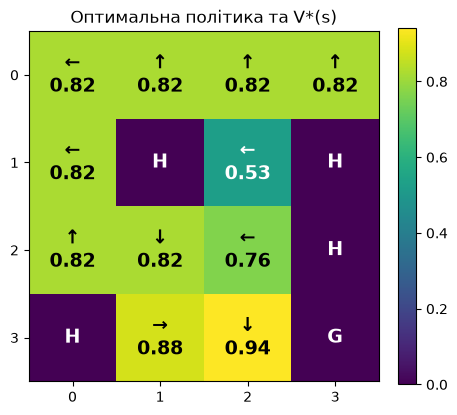

Оптимальна політика (стрілки):
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


In [7]:
def plot_policy(policy, V, title='Оптимальна політика та V*(s)'):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(V.reshape(4, 4), cmap='viridis')
    for s in range(n_states):
        r, c = divmod(s, 4)
        cell = desc[r, c]
        if cell in 'HG':
            label = cell
        else:
            label = f'{arrows[policy[s]]}\n{V[s]:.2f}'
        color = 'white' if V[s] < V.max() * 0.6 else 'black'
        ax.text(c, r, label, ha='center', va='center', fontsize=14, color=color, fontweight='bold')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

plot_policy(optimal_policy, optimal_V)

print('Оптимальна політика (стрілки):')
for r in range(4):
    print(' '.join(desc[r, c] if desc[r, c] in 'HG' else arrows[optimal_policy[4 * r + c]] for c in range(4)))

## Крок 5. Обчислювальні експерименти

### 5.1 Якість оптимальної політики у порівнянні з випадковою

Оцінимо частку успішних епізодів (досягнення `G`) на 2000 запусках для оптимальної та випадкової політик.

In [8]:
def evaluate_policy(env, policy, n_episodes=2000, max_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    successes, lengths = 0, []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1e9)))
        for t in range(max_steps):
            a = policy[state] if policy is not None else env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(a)
            if terminated or truncated:
                break
        successes += reward
        lengths.append(t + 1)
    return successes / n_episodes, np.mean(lengths)

env_eval = gym.make('FrozenLake-v1')          # без рендерингу — швидше
env_eval.action_space.seed(0)
sr_opt, len_opt = evaluate_policy(env_eval, optimal_policy)
sr_rnd, len_rnd = evaluate_policy(env_eval, None)
print(f'Оптимальна політика: успіх {sr_opt:.1%}, середня довжина епізоду {len_opt:.1f}')
print(f'Випадкова політика : успіх {sr_rnd:.1%}, середня довжина епізоду {len_rnd:.1f}')
print(f'Теоретична ймовірність успіху зі старту V*(0) = {optimal_V[0]:.4f}')

Оптимальна політика: успіх 74.6%, середня довжина епізоду 45.4
Випадкова політика : успіх 1.2%, середня довжина епізоду 7.5
Теоретична ймовірність успіху зі старту V*(0) = 0.8235


### 5.2 Вплив коефіцієнта дисконтування $\gamma$

Коефіцієнт дисконтування $\gamma$ визначає, наскільки «знецінюються» (стискаються) майбутні винагороди: при малому $\gamma$ агент близькозорий, при $\gamma \to 1$ — далекоглядний. Проведемо ітерацію за політиками для різних $\gamma$ і порівняємо кількість ітерацій, час, $V^*(0)$ та фактичну частку успіхів.

In [9]:
import time

gammas = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
results = []
policies = {}
for g in gammas:
    t0 = time.perf_counter()
    pol, V, it = policy_iteration(env, gamma=g, verbose=False)
    dt = time.perf_counter() - t0
    sr, ln = evaluate_policy(env_eval, pol, n_episodes=2000)
    policies[g] = pol
    results.append((g, it, dt, V[0], sr, ln))

print(f"{'gamma':>6} | {'ітерацій':>8} | {'час, с':>7} | {'V*(0)':>7} | {'успіх':>6} | {'дов. епізоду':>12}")
print('-' * 62)
for g, it, dt, v0, sr, ln in results:
    print(f'{g:>6} | {it:>8} | {dt:>7.3f} | {v0:>7.4f} | {sr:>6.1%} | {ln:>12.1f}')

 gamma | ітерацій |  час, с |   V*(0) |  успіх | дов. епізоду
--------------------------------------------------------------
   0.1 |        5 |   0.004 |  0.0000 |  43.1% |         28.3
   0.3 |        5 |   0.003 |  0.0000 |  43.1% |         28.3
   0.5 |        5 |   0.003 |  0.0004 |  43.1% |         28.3
   0.7 |        5 |   0.005 |  0.0045 |  43.1% |         28.3
   0.9 |        6 |   0.016 |  0.0689 |  73.2% |         41.7
  0.95 |        6 |   0.023 |  0.1805 |  73.2% |         41.7
  0.99 |        7 |   0.055 |  0.5420 |  74.6% |         45.4
   1.0 |        7 |   0.067 |  0.8235 |  74.6% |         45.4


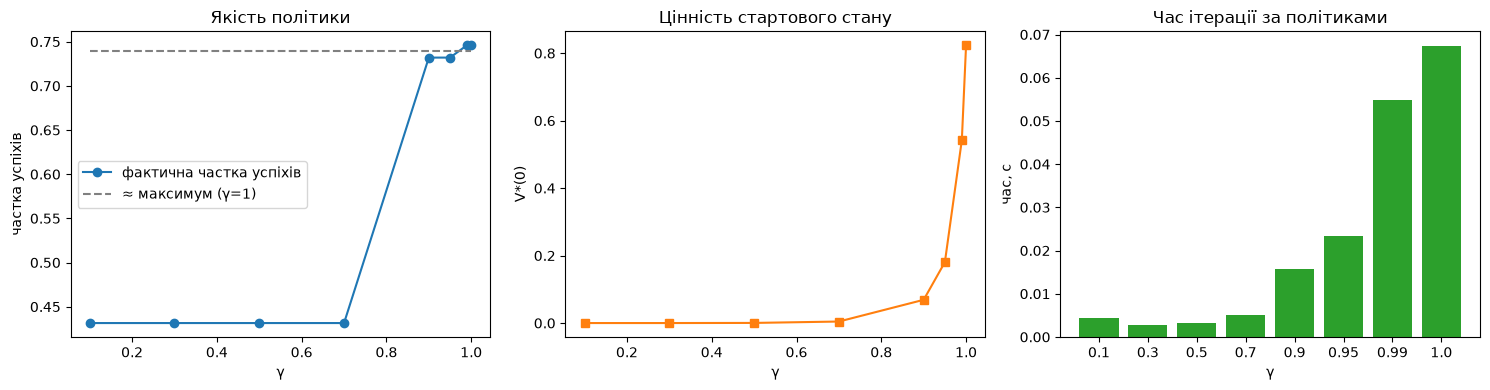

Політика для γ=0.1:
  ↓ ↑ → ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G
Політика для γ=1.0:
  ← ↑ ↑ ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G


In [10]:
res = np.array(results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(res[:, 0], res[:, 4], 'o-', label='фактична частка успіхів')
axes[0].plot(res[:, 0], [0.74] * len(res), '--', color='gray', label='≈ максимум (γ=1)')
axes[0].set_xlabel('γ'); axes[0].set_ylabel('частка успіхів'); axes[0].set_title('Якість політики'); axes[0].legend()
axes[1].plot(res[:, 0], res[:, 3], 's-', color='tab:orange')
axes[1].set_xlabel('γ'); axes[1].set_ylabel('V*(0)'); axes[1].set_title('Цінність стартового стану')
axes[2].bar([str(g) for g in res[:, 0]], res[:, 2], color='tab:green')
axes[2].set_xlabel('γ'); axes[2].set_ylabel('час, с'); axes[2].set_title('Час ітерації за політиками')
plt.tight_layout()
plt.show()

# Політики для γ=0.1 та γ=1.0
for g in (0.1, 1.0):
    print(f'Політика для γ={g}:')
    for r in range(4):
        print('  ' + ' '.join(desc[r, c] if desc[r, c] in 'HG' else arrows[policies[g][4 * r + c]] for c in range(4)))

### 5.3 Детерміноване середовище (`is_slippery=False`)

Для порівняння розв'яжемо задачу без ковзання — тоді оптимальна політика веде агента до цілі найкоротшим шляхом із гарантованим успіхом.

Policy-Iteration converged at step 7.
Успіх: 100%, довжина епізоду: 6 кроків


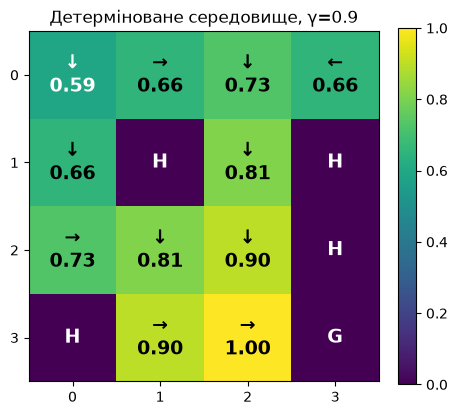

In [11]:
env_det = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
P_slippery = P
P = env_det.unwrapped.P                   # функції використовують глобальну модель P
det_policy, det_V, det_it = policy_iteration(env_det, gamma=0.9)
sr_det, len_det = evaluate_policy(env_det, det_policy, n_episodes=200)
print(f'Успіх: {sr_det:.0%}, довжина епізоду: {len_det:.0f} кроків')
plot_policy(det_policy, det_V, title='Детерміноване середовище, γ=0.9')
P = P_slippery                             # повертаємо модель слизького озера

## Висновки

1. **Середовище.** `FrozenLake-v1` — скінченний MDP: 16 станів, 4 дії, стохастичні переходи (рух в обраному напрямку лише з імовірністю 1/3) і розріджена винагорода (+1 тільки в `G`). Оскільки модель $P(s'\mid s,a)$ відома, задачу розв'язуємо методами динамічного програмування.

2. **`compute_value_function()`** реалізує оцінювання політики — ітеративне розв'язання рівняння Беллмана для очікування. Для наївної політики «завжди вправо» $V(0)\approx 0.03$: агент майже завжди падає в ополонку.

3. **`policy_iteration()`** збіглася за **7 ітерацій** (при $\gamma=1$). Отримана $V^*$ (напр. $V^*(0)=0.8235$, $V^*(14)=0.9412$) збігається зі значеннями агента бібліотеки `FrozenLakeDP` вище, що підтверджує коректність реалізації.

4. **Оптимальна політика** не є «найкоротшим шляхом». У стартовому стані агент обирає `←`, у верхньому рядку — `↑`, тобто навмисно «упирається» в стіну: так ковзання може віднести його лише в безпечний бік, а не в ополонку. Агент жертвує швидкістю заради безпеки — середня довжина епізоду ≈ 45 кроків, а частка успіхів **74.6 % проти 1.2 %** у випадкової політики.
   Теоретична ймовірність успіху $V^*(0)=0.82$ вища за емпіричні 74.6 %, бо середовище обрізає епізод після 100 кроків (`TimeLimit`), а обережна політика інколи не встигає дійти до цілі.

5. **Вплив коефіцієнта дисконтування $\gamma$.**
   - При $\gamma \le 0.7$ майбутня винагорода «стискається» майже до нуля ($V^*(0)\le 0.005$), різниця між діями в далеких від цілі станах мізерна, і агент обирає менш обережні дії (напр. `↓` у стартовому стані) — успіх лише **43 %**.
   - При $\gamma = 0.9\text{–}0.95$ успіх зростає до **73 %**, а при $\gamma \ge 0.99$ отримуємо ту саму оптимальну політику, що й при $\gamma=1$ (**74.6 %**).
   - Зі збільшенням $\gamma$ зростає кількість ітерацій (5 → 7) і час обчислень (≈ у 10+ разів), бо ітерації Беллмана при $\gamma\to1$ збігаються повільніше.

   Отже, для задач з рідкісною кінцевою винагородою $\gamma$ варто обирати близьким до 1.

6. **Стохастичність — головне джерело складності.** У детермінованому варіанті (`is_slippery=False`) оптимальна політика досягає цілі за **6 кроків зі 100 % успіху**, тоді як у слизькому озері навіть оптимальна політика успішна приблизно в 3 епізодах із 4.